# PV-BESS optimizer (Julia)

Julia translation of the PV BESS optimizer. This notebook mirrors the Python workflow with JuMP and HiGHS.

## Dependencies

If the Julia packages are not installed yet, run the following once in a Julia REPL or in a setup cell:

`import Pkg; Pkg.add(["CSV", "DataFrames", "Dates", "Plots", "JuMP", "HiGHS", "IJulia"])`

## Imports

In [1]:
using CSV
using DataFrames
using Dates
using Plots

include("scheduler_three_market.jl")
using .Scheduler

default(size=(1000, 600)) # Set default plot size

# Set input parameters

In [2]:
p_limit = 10.0
gradient_limit = 100.0
storage_capacity = 10.0
p_charge_max = 5.0
p_discharge_max = 5.0
efficiency = 0.95
start_soc = 0.0
end_soc = 0.0
number_of_cycles = 2 * 7

number_of_weeks = 52
year = "2025"

strike_price = 284.3
is_negative_price_hour_rule = false

year_data = Dict(
    "2024" => (
        market_value=46.24,
        daa_path="data/2024/DA/2024_daa.csv",
        ida_path="data/2024/IDA/2024_ida.csv",
        idc_path="data/2024/ID1/2024_id1.csv",
        pv_path="data/2024/PV/2024_pv.csv",
        start_timestamp="2024-01-01T00:00:00",
    ),
    "2025" => (
        market_value=45.08,
        daa_path="data/2025/DA/2025_daa.csv",
        ida_path="data/2025/IDA/2025_ida.csv",
        idc_path="data/2025/ID1/2025_id1.csv",
        pv_path="data/2025/PV/2025_pv.csv",
        start_timestamp="2024-12-30T00:00:00",
    ),
)

market_value = year_data[year].market_value

45.08

## Utility functions

In [3]:
# Load time series data
function load_timeseries(path::AbstractString, value_name::Symbol)
    # On Linux, CSV.jl may parse empty cells as Missing, so we need to handle this explicitly
    df = CSV.read(path, DataFrame; missingstring=["", "NA", "NULL", "NaN"], strict=false)
    rename!(df, names(df)[1] => :timestamp, names(df)[2] => value_name)
    df.timestamp = DateTime.(df.timestamp, dateformat"yyyy-mm-dd HH:MM:SS")
    
    # Replace any Missing values with 0.0 and convert to Float64
    if eltype(df[!, value_name]) >: Missing
        df[!, value_name] = coalesce.(df[!, value_name], 0.0)
    end
    df[!, value_name] = Float64.(df[!, value_name])
    
    sort!(df, :timestamp)
    return df
end

# Slice a DataFrame based on a timestamp range
function timestamp_slice(df::DataFrame, start_ts::DateTime, end_ts::DateTime)
    return df[(df.timestamp .>= start_ts) .& (df.timestamp .<= end_ts), :]
end

# Calculate the permissible power change (delta_p_perm) based on the gradient limit and time step
function calculate_delta_p_perm(gradient_limit, p_charge_max, p_discharge_max; delta_t=15.0)
    tau = 100.0 / gradient_limit
    power_span = min(p_charge_max, p_discharge_max)

    if tau <= 2 * delta_t && tau > 1.0
        if tau <= delta_t
            p_perm = power_span / 2 * tau / delta_t
        else
            p_remaining = power_span * (tau - delta_t) / tau
            p_perm = (power_span - p_remaining) / 2 + p_remaining
        end
        delta_p_perm = power_span - p_perm
    elseif tau > 2 * delta_t
        delta_p_perm = 0.0
        println("Gradient too low!")
    elseif tau == 1.0
        delta_p_perm = power_span
    else
        error("Unsupported gradient configuration for tau=$(tau).")
    end

    return tau, delta_p_perm
end

# Calculate annual energy from a series of power values (in kW) sampled every 15 minutes
annual_energy(series) = sum(series) * 15 / 60

annual_energy (generic function with 1 method)

## Load data

In [4]:
scenario = year_data[year]

daa = load_timeseries(scenario.daa_path, :daa_price)
ida = load_timeseries(scenario.ida_path, :ida_price)
idc = load_timeseries(scenario.idc_path, :idc_price)
pv = load_timeseries(scenario.pv_path, :pv_output)
pv.pv_output = max.(0.0, pv.pv_output)

market_premium = select(daa, :timestamp)
market_premium[!, :strike_price] = fill(strike_price, nrow(market_premium))
market_premium[!, :market_value] = fill(market_value, nrow(market_premium))
market_premium[!, :market_premium] = market_premium.strike_price .- market_premium.market_value

if is_negative_price_hour_rule
    market_premium[daa.daa_price .< 0, :market_premium] .= 0.0
end

tau, delta_p_perm = calculate_delta_p_perm(gradient_limit, p_charge_max, p_discharge_max)
println("time constant (tau): $(round(tau, digits=2)) minutes")
println("Power gradient (delta_p_perm): $(round(delta_p_perm, digits=2)) MW per 15 minutes")

time constant (tau): 1.0 minutes
Power gradient (delta_p_perm): 5.0 MW per 15 minutes


## Get schedules

In [5]:
start_ts = DateTime(scenario.start_timestamp)
end_ts = start_ts + Day(7) - Minute(15)
result_list = DataFrame[]

for week in 1:number_of_weeks
    println("start/end $(start_ts) $(end_ts)")

    pv_slice = timestamp_slice(pv, start_ts, end_ts)
    daa_slice = timestamp_slice(daa, start_ts, end_ts)
    ida_slice = timestamp_slice(ida, start_ts, end_ts)
    idc_slice = timestamp_slice(idc, start_ts, end_ts)
    premium_slice = timestamp_slice(market_premium, start_ts, end_ts)

    pv_vector = collect(pv_slice.pv_output)
    daa_price_vector = collect(daa_slice.daa_price)
    ida_price_vector = collect(ida_slice.ida_price)
    idc_price_vector = collect(idc_slice.idc_price)
    market_premium_vector = collect(premium_slice.market_premium)

    println("PV vector length: $(length(pv_vector)) DAA: $(length(daa_price_vector)) IDA: $(length(ida_price_vector)) IDC: $(length(idc_price_vector)) Premium: $(length(market_premium_vector)) Delta P_perm: $(delta_p_perm)")

    if any(isempty, (pv_vector, daa_price_vector, ida_price_vector, idc_price_vector, market_premium_vector))
        error("PV output, DAA price, IDA price, IDC price, and market premium vectors cannot be empty.")
    end

    if length(unique([length(pv_vector), length(daa_price_vector), length(ida_price_vector), length(idc_price_vector), length(market_premium_vector)])) != 1
        error("PV output, DAA price, IDA price, IDC price, and market premium vectors must have the same length.")
    end

    daa_result = get_daa_schedule(
        pv_vector,
        daa_price_vector,
        market_premium_vector,
        p_limit,
        storage_capacity,
        p_charge_max,
        p_discharge_max,
        delta_p_perm,
        number_of_cycles,
        efficiency,
        start_soc,
        end_soc,
    )

    ida_result = get_ida_schedule(
        ida_price_vector,
        market_premium_vector,
        daa_result.pv_output,
        p_limit,
        storage_capacity,
        p_charge_max,
        p_discharge_max,
        delta_p_perm,
        daa_result.p_charge_daa,
        daa_result.p_discharge_daa,
        daa_result.p_curtailed_daa,
        number_of_cycles,
        efficiency,
        start_soc,
        end_soc,
    )

    idc_result = get_idc_schedule(
        idc_price_vector,
        market_premium_vector,
        daa_result.pv_output,
        p_limit,
        storage_capacity,
        p_charge_max,
        p_discharge_max,
        delta_p_perm,
        ida_result.p_charge_daa_ida,
        ida_result.p_discharge_daa_ida,
        ida_result.p_curtailed_daa_ida,
        number_of_cycles,
        efficiency,
        start_soc,
        end_soc,
    )

    result = DataFrame(
        timestamp=collect(start_ts:Minute(15):end_ts),
        daa_price=daa_result.daa,
        ida_price=ida_result.ida,
        idc_price=idc_result.idc,
        market_premium=daa_result.market_premium,
        pv_output=daa_result.pv_output,
        p_charge_daa=daa_result.p_charge_daa,
        p_discharge_daa=daa_result.p_discharge_daa,
        p_curtailed_daa=daa_result.p_curtailed_daa,
        soc_daa=daa_result.soc,
        injection_power_daa=daa_result.p_inject_daa,
        p_charge_ida=ida_result.p_charge_ida,
        p_discharge_ida=ida_result.p_discharge_ida,
        p_close_charge_daa=ida_result.p_close_charge_daa,
        p_close_discharge_daa=ida_result.p_close_discharge_daa,
        p_curtailed_ida=ida_result.p_curtailed_ida,
        p_close_curtailed_daa=ida_result.p_close_curtailed_daa,
        p_charge_daa_ida=ida_result.p_charge_daa_ida,
        p_discharge_daa_ida=ida_result.p_discharge_daa_ida,
        p_curtailed_daa_ida=ida_result.p_curtailed_daa_ida,
        soc_ida=ida_result.soc,
        injection_power_ida=ida_result.p_inject_ida,
        p_charge_idc=idc_result.p_charge_idc,
        p_discharge_idc=idc_result.p_discharge_idc,
        p_close_charge_daa_ida=idc_result.p_close_charge_daa_ida,
        p_close_discharge_daa_ida=idc_result.p_close_discharge_daa_ida,
        p_curtailed_idc=idc_result.p_curtailed_idc,
        p_close_curtailed_daa_ida=idc_result.p_close_curtailed_daa_ida,
        p_charge_daa_ida_idc=idc_result.p_charge_daa_ida_idc,
        p_discharge_daa_ida_idc=idc_result.p_discharge_daa_ida_idc,
        p_curtailed_daa_ida_idc=idc_result.p_curtailed_daa_ida_idc,
        soc_idc=idc_result.soc,
        injection_power_idc=idc_result.p_inject_idc,
    )

    push!(result_list, result)
    start_ts += Day(7)
    end_ts += Day(7)
end

results = vcat(result_list...)

start/end 2024-12-30T00:00:00 2025-01-05T23:45:00
PV vector length: 672 DAA: 672 IDA: 672 IDC: 672 Premium: 672 Delta P_perm: 5.0
Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
MIP has 9410 rows; 4705 cols; 23044 nonzeros; 1344 integer variables (1344 binary)
Coefficient ranges:
  Matrix  [9e-04, 5e+00]
  Cost    [6e+01, 1e+02]
  Bound   [1e+00, 1e+00]
  RHS     [9e-04, 1e+02]
Presolving model
6248 rows, 3761 cols, 17996 nonzeros  0s
3768 rows, 2892 cols, 11032 nonzeros  0s
2522 rows, 2552 cols, 8380 nonzeros  0s
1888 rows, 2316 cols, 6715 nonzeros  0s
825 rows, 1266 cols, 2882 nonzeros  0s
825 rows, 950 cols, 2566 nonzeros  0s
823 rows, 945 cols, 2555 nonzeros  0s
Presolve reductions: rows 823(-8587); columns 945(-3760); nonzeros 2555(-20489) 

Solving MIP model with:
   823 rows
   945 cols (202 binary, 0 integer, 0 implied int., 743 continuous, 0 domain fixed)
   2555 nonzeros

Src: B => Branching; C => Centr

Row,timestamp,daa_price,ida_price,idc_price,market_premium,pv_output,p_charge_daa,p_discharge_daa,p_curtailed_daa,soc_daa,injection_power_daa,p_charge_ida,p_discharge_ida,p_close_charge_daa,p_close_discharge_daa,p_curtailed_ida,p_close_curtailed_daa,p_charge_daa_ida,p_discharge_daa_ida,p_curtailed_daa_ida,soc_ida,injection_power_ida,p_charge_idc,p_discharge_idc,p_close_charge_daa_ida,p_close_discharge_daa_ida,p_curtailed_idc,p_close_curtailed_daa_ida,p_charge_daa_ida_idc,p_discharge_daa_ida_idc,p_curtailed_daa_ida_idc,soc_idc,injection_power_idc
,DateTime,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,2024-12-30T00:00:00,71.73,86.5859,102.809,239.22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-12-30T00:15:00,71.73,83.5182,87.5729,239.22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-12-30T00:30:00,71.73,75.5197,79.3946,239.22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-12-30T00:45:00,71.73,68.2327,73.8446,239.22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2024-12-30T01:00:00,68.6,86.0791,77.7387,239.22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2024-12-30T01:15:00,68.6,79.666,67.5957,239.22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2024-12-30T01:30:00,68.6,72.6986,76.2637,239.22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2024-12-30T01:45:00,68.6,67.1978,79.3997,239.22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2024-12-30T02:00:00,68.6,79.6909,81.9536,239.22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Plot results

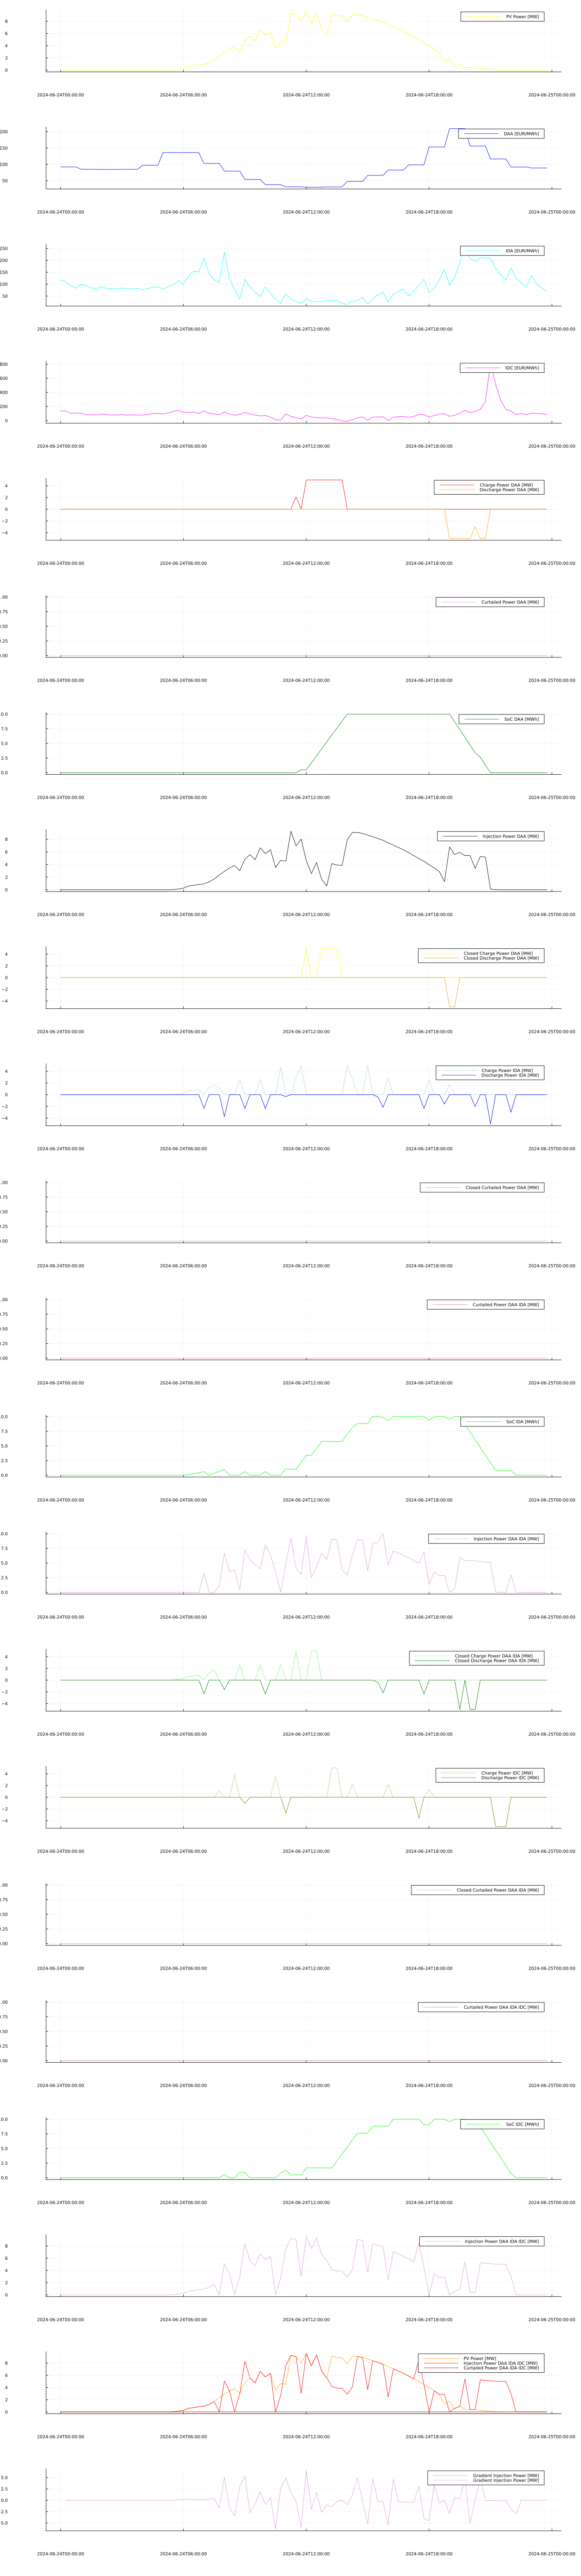

In [39]:
plot_start = DateTime("2024-06-24T00:00:00")
plot_end = DateTime("2024-06-24T23:45:00")
results_slice = results[(results.timestamp .>= plot_start) .& (results.timestamp .<= plot_end), :]

# Explicit y-labels and larger left margin prevent labels from being clipped in tall combined layouts
plots = [
    plot(results_slice.timestamp, results_slice.pv_output; label="PV Power [MW]", ylabel="PV Power [MW]", color=:yellow, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.daa_price; label="DAA [EUR/MWh]", ylabel="Price [EUR/MWh]", color=:blue, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.ida_price; label="IDA [EUR/MWh]", ylabel="Price [EUR/MWh]", color=:cyan, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.idc_price; label="IDC [EUR/MWh]", ylabel="Price [EUR/MWh]", color=:magenta, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.p_charge_daa; label="Charge Power DAA [MW]", ylabel="Power [MW]", color=:red, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.p_curtailed_daa; label="Curtailed Power DAA [MW]", ylabel="Power [MW]", color=:violet, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.soc_daa; label="SoC DAA [MWh]", ylabel="SoC [MWh]", color=:green, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.injection_power_daa; label="Injection Power DAA [MW]", ylabel="Power [MW]", color=:black, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.p_close_charge_daa; label="Closed Charge Power DAA [MW]", ylabel="Power [MW]", color=:yellow, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.p_charge_ida; label="Charge Power IDA [MW]", ylabel="Power [MW]", color=:lightblue, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.p_close_curtailed_daa; label="Closed Curtailed Power DAA [MW]", ylabel="Power [MW]", color=:plum, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.p_curtailed_daa_ida; label="Curtailed Power DAA IDA [MW]", ylabel="Power [MW]", color=:lightcoral, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.soc_ida; label="SoC IDA [MWh]", ylabel="SoC [MWh]", color=:lime, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.injection_power_ida; label="Injection Power DAA IDA [MW]", ylabel="Power [MW]", color=:plum, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.p_close_charge_daa_ida; label="Closed Charge Power DAA IDA [MW]", ylabel="Power [MW]", color=:lightgreen, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.p_charge_idc; label="Charge Power IDC [MW]", ylabel="Power [MW]", color=RGB(0.75, 0.81, 0.49), grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.p_close_curtailed_daa_ida; label="Closed Curtailed Power DAA IDA [MW]", ylabel="Power [MW]", color=:plum, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.p_curtailed_daa_ida_idc; label="Curtailed Power DAA IDA IDC [MW]", ylabel="Power [MW]", color=:lightcoral, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.soc_idc; label="SoC IDC [MWh]", ylabel="SoC [MWh]", color=:lime, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.injection_power_idc; label="Injection Power DAA IDA IDC [MW]", ylabel="Power [MW]", color=:plum, grid=true, legend=:topright),
    plot(results_slice.timestamp, results_slice.pv_output; label="PV Power [MW]", ylabel="PV Power [MW]", color=:orange, grid=true, legend=:topright),
    plot(results_slice.timestamp, fill(NaN, nrow(results_slice)); label="Gradient Injection Power [MW]", ylabel="Gradient [MW]", color=:plum, grid=true, legend=:topright),
]

plot!(plots[5], results_slice.timestamp, -results_slice.p_discharge_daa; label="Discharge Power DAA [MW]", color=:orange)
plot!(plots[9], results_slice.timestamp, -results_slice.p_close_discharge_daa; label="Closed Discharge Power DAA [MW]", color=:goldenrod)
plot!(plots[10], results_slice.timestamp, -results_slice.p_discharge_ida; label="Discharge Power IDA [MW]", color=:blue)
plot!(plots[15], results_slice.timestamp, -results_slice.p_close_discharge_daa_ida; label="Closed Discharge Power DAA IDA [MW]", color=:green)
plot!(plots[16], results_slice.timestamp, -results_slice.p_discharge_idc; label="Discharge Power IDC [MW]", color=:olive)
plot!(plots[21], results_slice.timestamp, results_slice.injection_power_idc; label="Injection Power DAA IDA IDC [MW]", color=:red)
plot!(plots[21], results_slice.timestamp, results_slice.p_curtailed_daa_ida_idc; label="Curtailed Power DAA IDA IDC [MW]", color=:darkred)

injection_power_gradient_idc = vcat(NaN, diff(results_slice.injection_power_idc))
plot!(plots[22], results_slice.timestamp, injection_power_gradient_idc, label="Gradient Injection Power [MW]", color=:plum)

combined_plot = plot(
    plots...;
    layout=(22, 1),
    size=(1400, 6200),
    left_margin=16Plots.mm,
    right_margin=10Plots.mm,
    top_margin=4Plots.mm,
    bottom_margin=6Plots.mm,
    link=:x,
    xrotation=0,
    legendfontsize=7,
    guidefontsize=8,
    tickfontsize=7,
)
savefig(combined_plot, "results_julia.png")
combined_plot

## Calculate annual energies

In [40]:
results[!, :p_limit] = fill(p_limit, nrow(results))
results[!, :pv_output_clipped] = min.(results.pv_output, results.p_limit)

pv_production = annual_energy(results.pv_output)
injected_energy_daa = annual_energy(results.injection_power_daa)
curtailed_energy_daa = annual_energy(results.p_curtailed_daa)
discharge_energy_daa = annual_energy(results.p_discharge_daa)
charge_energy_daa = annual_energy(results.p_charge_daa)

injected_energy_ida = annual_energy(results.injection_power_ida)
curtailed_energy_ida = annual_energy(results.p_curtailed_daa_ida)
closed_curtailed_daa_energy = annual_energy(results.p_close_curtailed_daa)
discharge_energy_ida = annual_energy(results.p_discharge_ida)
charge_energy_ida = annual_energy(results.p_charge_ida)
closed_discharge_daa_energy = annual_energy(results.p_close_discharge_daa)
closed_charge_daa_energy = annual_energy(results.p_close_charge_daa)
discharge_energy_daa_ida = annual_energy(results.p_discharge_daa_ida)
charge_energy_daa_ida = annual_energy(results.p_charge_daa_ida)

injected_energy_idc = annual_energy(results.injection_power_idc)
curtailed_energy_idc = annual_energy(results.p_curtailed_daa_ida_idc)
closed_curtailed_daa_ida_energy = annual_energy(results.p_close_curtailed_daa_ida)
discharge_energy_idc = annual_energy(results.p_discharge_idc)
charge_energy_idc = annual_energy(results.p_charge_idc)
closed_discharge_daa_ida_energy = annual_energy(results.p_close_discharge_daa_ida)
closed_charge_daa_ida_energy = annual_energy(results.p_close_charge_daa_ida)
discharge_energy_daa_ida_idc = annual_energy(results.p_discharge_daa_ida_idc)
charge_energy_daa_ida_idc = annual_energy(results.p_charge_daa_ida_idc)

println("Annual Energies:")
println("==========================================")
println("PV Production: $(round(pv_production, digits=2)) MWh")
println("Injected Energy DAA: $(round(injected_energy_daa, digits=2)) MWh")
println("Curtailed Energy DAA: $(round(curtailed_energy_daa, digits=2)) MWh")
println("Charge Energy DAA: $(round(charge_energy_daa, digits=2)) MWh")
println("Discharge Energy DAA: $(round(discharge_energy_daa, digits=2)) MWh")
println("Injected Energy IDA: $(round(injected_energy_ida, digits=2)) MWh")
println("Curtailed Energy IDA: $(round(curtailed_energy_ida, digits=2)) MWh")
println("Injected Energy IDC: $(round(injected_energy_idc, digits=2)) MWh")
println("Curtailed Energy IDC: $(round(curtailed_energy_idc, digits=2)) MWh")
println("")

results[!, :pv_direct_market_profit_reference] = results.daa_price .* results.pv_output .* 15 / 60
results[!, :pv_direct_market_profit_clipped_reference] = results.daa_price .* results.pv_output_clipped .* 15 / 60

condition_daa_positive = results.daa_price .>= 0
annual_pv_production = annual_energy(results.pv_output)
annual_pv_production_clipped = annual_energy(results.pv_output_clipped)
annual_pv_direct_market_profit_reference = sum(results.pv_direct_market_profit_reference)
annual_pv_direct_market_profit_clipped_reference = sum(results.pv_direct_market_profit_clipped_reference)

if is_negative_price_hour_rule
    annual_pv_production = annual_energy(results[condition_daa_positive, :pv_output])
    annual_pv_production_clipped = annual_energy(results[condition_daa_positive, :pv_output_clipped])
    annual_pv_direct_market_profit_reference = sum(results[condition_daa_positive, :pv_direct_market_profit_reference])
    annual_pv_direct_market_profit_clipped_reference = sum(results[condition_daa_positive, :pv_direct_market_profit_clipped_reference])
end

results[!, :injected_power_direct_market_profit_daa] = results.daa_price .* results.injection_power_daa .* 15 / 60
annual_injected_energy_direct_market_profit_daa = sum(results.injected_power_direct_market_profit_daa)

results[!, :ida_market_profit] = (results.p_discharge_ida .- results.p_charge_ida .+ results.p_close_charge_daa .- results.p_close_discharge_daa .+ results.p_close_curtailed_daa .- results.p_curtailed_ida) .* results.ida_price ./ 4
annual_ida_market_profit = sum(results.ida_market_profit)

results[!, :idc_market_profit] = (results.p_discharge_idc .- results.p_charge_idc .+ results.p_close_charge_daa_ida .- results.p_close_discharge_daa_ida .+ results.p_close_curtailed_daa_ida .- results.p_curtailed_idc) .* results.idc_price ./ 4
annual_idc_market_profit = sum(results.idc_market_profit)

market_premium_injected_energy_idc = annual_energy(results.injection_power_idc) * (strike_price - market_value)
if is_negative_price_hour_rule
    market_premium_injected_energy_idc = annual_energy(results[condition_daa_positive, :injection_power_idc]) * (strike_price - market_value)
end
market_premium_injected_energy_idc = max(0.0, market_premium_injected_energy_idc)

market_premium_pv_production = max(0.0, annual_pv_production * (strike_price - market_value))
market_premium_pv_production_clipped = max(0.0, annual_pv_production_clipped * (strike_price - market_value))

annual_profit_pv_only_reference = market_premium_pv_production + annual_pv_direct_market_profit_reference
annual_profit_pv_only_clipped_reference = market_premium_pv_production_clipped + annual_pv_direct_market_profit_clipped_reference
annual_profit_pv_bess = market_premium_injected_energy_idc + annual_injected_energy_direct_market_profit_daa + annual_ida_market_profit + annual_idc_market_profit
annual_bess_profit = annual_profit_pv_bess - annual_pv_direct_market_profit_clipped_reference - market_premium_pv_production_clipped
specific_annual_bess_profit = annual_bess_profit / storage_capacity

println("Annual Direct Market Profits:")
println("=============================")
println("Annual PV Direct Market Profit (Reference): $(round(annual_pv_direct_market_profit_reference, digits=2)) EUR")
println("Annual PV Direct Market Profit Clipped (Reference): $(round(annual_pv_direct_market_profit_clipped_reference, digits=2)) EUR")
println("Annual Injected Energy Direct Market Profit (DAA): $(round(annual_injected_energy_direct_market_profit_daa, digits=2)) EUR")
println("Annual IDA Market Profit: $(round(annual_ida_market_profit, digits=2)) EUR")
println("Annual IDC Market Profit: $(round(annual_idc_market_profit, digits=2)) EUR")
println("Annual Market Premium PV + BESS (IDC): $(round(market_premium_injected_energy_idc, digits=2)) EUR")
println("Annual Market Premium PV only: $(round(market_premium_pv_production, digits=2)) EUR")
println("Annual profit PV only (reference): $(round(annual_profit_pv_only_reference, digits=2)) EUR")
println("Annual profit PV only clipped (reference): $(round(annual_profit_pv_only_clipped_reference, digits=2)) EUR")
println("Annual profit PV + BESS (DAA IDA IDC): $(round(annual_profit_pv_bess, digits=2)) EUR")
println("Annual BESS profit (DAA IDA IDC): $(round(annual_bess_profit, digits=2)) EUR")
println("Specific Annual BESS profit (DAA IDA IDC): $(round(specific_annual_bess_profit, digits=2)) EUR/MWh")

CSV.write("results_julia.csv", results)

Annual Energies:
PV Production: 12595.27 MWh
Injected Energy DAA: 12317.77 MWh
Curtailed Energy DAA: 0.0 MWh
Charge Energy DAA: 2846.18 MWh
Discharge Energy DAA: 2568.68 MWh
Injected Energy IDA: 12254.71 MWh
Curtailed Energy IDA: 0.0 MWh
Injected Energy IDC: 12236.38 MWh
Curtailed Energy IDC: 33.28 MWh

Annual Direct Market Profits:
Annual PV Direct Market Profit (Reference): 607240.63 EUR
Annual PV Direct Market Profit Clipped (Reference): 607240.43 EUR
Annual Injected Energy Direct Market Profit (DAA): 883740.45 EUR
Annual IDA Market Profit: 137034.4 EUR
Annual IDC Market Profit: 112792.68 EUR
Annual Market Premium PV + BESS (IDC): 2.92718724e6 EUR
Annual Market Premium PV only: 3.01304136e6 EUR
Annual profit PV only (reference): 3.620282e6 EUR
Annual profit PV only clipped (reference): 3.62028116e6 EUR
Annual profit PV + BESS (DAA IDA IDC): 4.06075477e6 EUR
Annual BESS profit (DAA IDA IDC): 440473.62 EUR
Specific Annual BESS profit (DAA IDA IDC): 44047.36 EUR/MWh


"results_julia.csv"